In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from typing import TypedDict
import numpy as np
class FoldsModelMetrics(TypedDict):
    """Model metrics per fold."""
    roc_auc:float
    f1:float
    top_k:float
    accuracy:float
    confusion_matrix:np.ndarray
    precision:float
    precision:float

In [ ]:
dir(FoldsModelMetrics)

['__annotations__',
 '__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__optional_keys__',
 '__or__',
 '__orig_bases__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__required_keys__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__total__',
 '__weakref__',
 'clear',
 'copy',
 'fromkeys',
 'get',
 'items',
 'keys',
 'pop',
 'popitem',
 'setdefault',
 'update',
 'values']

In [2]:
import os
BASE_PATH = os.path.join("/", "content", "drive", "MyDrive", "projeto-apollo")
images = os.path.join(BASE_PATH, "data_arr.npy")
dataset = os.path.join(BASE_PATH, "mapping.csv")

In [3]:
import pandas as pd
import numpy as np

In [4]:
imgs = np.load(images)
df = pd.read_csv(dataset)

In [5]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV,KFold,train_test_split,cross_val_predict,StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, top_k_accuracy_score, classification_report, RocCurveDisplay, auc, accuracy_score, confusion_matrix, precision_score, recall_score
from sklearn.multiclass import OneVsRestClassifier

from sklearn.preprocessing import normalize

from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns
import umap

In [6]:
folds = 10

In [7]:
X = imgs
y = df.syndrome

In [9]:
y.value_counts().to_dict()

{300000034: 210,
 300000080: 198,
 100192430: 136,
 300000007: 115,
 300000082: 98,
 100610443: 89,
 300000018: 74,
 100180860: 67,
 100610883: 65,
 700018215: 64}

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [ ]:
#best_models = []
best_params = []
for metric in ['cosine', 'euclidean']:
  print("Testing for ",metric)

  model = KNeighborsClassifier(metric=metric)
  params = {
    'n_neighbors':np.arange(1,16),
  }
  gcv = GridSearchCV(
      model,
      params,
      cv=StratifiedKFold(n_splits=folds, random_state=42, shuffle=True),
      n_jobs=4
    )
  gcv.fit(X_train,y_train)
  best_model = gcv.best_estimator_
  print("Best: ",best_model)
  print(gcv.best_params_)
  best_params.append({**gcv.best_params_, "metric":metric})
  #best_models.append(best_model)

Testing for  cosine
Best:  KNeighborsClassifier(metric='cosine', n_neighbors=np.int64(10))
{'n_neighbors': np.int64(10)}
Testing for  euclidean
Best:  KNeighborsClassifier(metric='euclidean', n_neighbors=np.int64(15))
{'n_neighbors': np.int64(15)}


In [ ]:
def get_roc_curve(classes, pred, y):
  tprs = defaultdict(list)
  aucs = defaultdict(list)
  fprs = defaultdict(list)
  for i,c in enumerate(classes):
    y_test_binary = (y == c).astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, pred[:,i])
    tprs[c].append(tpr)
    fprs[c].append(fpr)
    aucs[c].append(auc(fpr,tpr))
    print(len(tpr), len(fpr))
    #sns.lineplot(x=fpr, y=tpr, label=f'{c} (AUC={auc(fpr,tpr)})')
  #sns.lineplot(x=[0,1], y=[0,1], linestyle='--')
  #plt.legend(loc='lower right')
  #plt.show()

  return fprs,tprs,aucs

In [ ]:
np.linspace(0.0, 1.0, 1000).shape

(1000,)

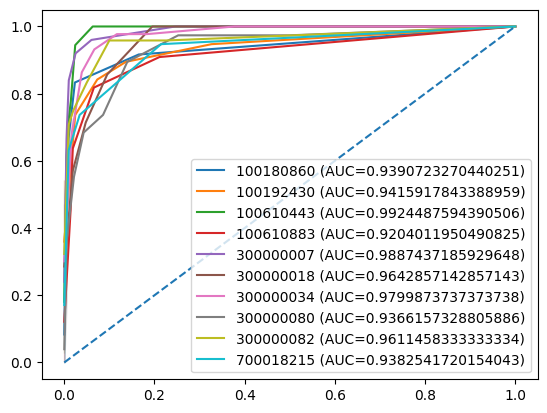

ROC AUC Score:  0.9562546610716431
F1 Score:  [0.72727273 0.69767442 0.84210526 0.63157895 0.82352941 0.61538462
 0.84536082 0.70731707 0.75555556 0.4       ]
Top-K Score:  0.8973214285714286
Accuracy:  0.7410714285714286
Confusion matrix:  [[ 8  2  2  0  0  0  0  0  0  0]
 [ 1 15  0  0  0  0  2  1  0  0]
 [ 0  0 16  0  0  0  1  0  1  0]
 [ 0  1  0  6  0  1  1  2  0  0]
 [ 0  0  0  0 21  2  2  0  0  0]
 [ 0  1  0  0  3  8  2  0  0  0]
 [ 0  1  0  0  0  0 41  0  1  1]
 [ 1  2  0  0  1  0  3 29  2  0]
 [ 0  1  0  1  1  0  1  3 17  0]
 [ 0  1  2  1  0  1  0  9  0  5]]
Precision:  0.7410714285714286
Recall:  0.7410714285714286


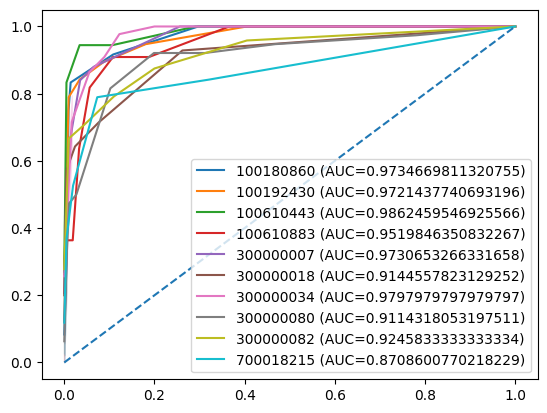

ROC AUC Score:  0.9458035649396155
F1 Score:  [0.7826087  0.69767442 0.88235294 0.64       0.76190476 0.72727273
 0.81481481 0.68181818 0.7804878  0.27272727]
Top-K Score:  0.8392857142857143
Accuracy:  0.7321428571428571
Confusion matrix:  [[ 9  1  0  1  0  0  0  1  0  0]
 [ 1 15  0  0  0  0  2  1  0  0]
 [ 0  1 15  0  0  0  2  0  0  0]
 [ 0  1  0  8  0  0  0  2  0  0]
 [ 0  1  0  0 16  0  6  2  0  0]
 [ 0  2  0  1  1  8  2  0  0  0]
 [ 0  0  0  0  0  0 44  0  0  0]
 [ 0  2  0  1  0  0  4 30  1  0]
 [ 0  0  0  1  0  0  2  5 16  0]
 [ 1  1  1  2  0  0  2  9  0  3]]
Precision:  0.7321428571428571
Recall:  0.7321428571428571


In [ ]:


y_train_np = y_train.to_numpy()
for params in best_params:


  cv = StratifiedKFold(n_splits=folds, random_state=42, shuffle=True)

  fprs_grid = np.linspace(0.0, 1.0, 100)
  tprs_history = {}
  aucs_history = defaultdict(list)

  fold_i = 0
  for train_idx, test_idx in cv.split(X_train, y_train_np):

    X_train_fold, X_test_fold = X_train[train_idx], X_train[test_idx]
    y_train_fold, y_test_fold = y_train_np[train_idx], y_train_np[test_idx]


    n_neighbors = params["n_neighbors"]
    metric = params["metric"]


    model = KNeighborsClassifier(n_neighbors=n_neighbors, metric=metric)
    model.fit(X_train_fold, y_train_fold)

    y_pred = model.predict_proba(X_test_fold)
    for i,class_ in enumerate(model.classes_):

      if(not class_ in tprs_history):
        tprs_history[class_] = []

      tprs_history[class_].append([])

      y_test_binary = (y_test_fold == model.classes_[i]).astype(int)
      fpr, tpr, _ = roc_curve(y_test_binary, y_pred[:,i])
      tprs_history[class_][fold_i].append(np.interp(fprs_grid, fpr, tpr))
      tprs_history[class_][fold_i][-1][0] = 0.0
      aucs_history[class_].append(auc(fpr, tpr))

    fold_i +=1

  #for i,class_ in enumerate(model.classes_):
  """
  selected_class = model.classes_[0]
  for j in range(folds):
    mean_tpr = np.mean(tprs_history[selected_class][j], axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(fprs_grid, mean_tpr)

    sns.lineplot(x=fprs_grid,y=mean_tpr,label=f"{selected_class} AUC={mean_auc} (fold {j+1})")
  plt.show()
  """

  y_pred_matrix = model.predict_proba(X_test)
  y_pred = model.predict(X_test)


  for i,c in enumerate(model.classes_):
    y_test_binary = (y_test == c).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_matrix[:,i])
    sns.lineplot(x=fpr, y=tpr, label=f'{c} (AUC={auc(fpr,tpr)})')
  sns.lineplot(x=[0,1], y=[0,1], linestyle='--')
  plt.legend(loc='lower right')
  plt.show()

  print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_matrix, multi_class="ovr"))
  print("F1 Score: ", f1_score(y_test, y_pred, average=None))
  print("Top-K Score: ",top_k_accuracy_score(y_test, y_pred_matrix))
  print("Accuracy: ",  accuracy_score(y_test, y_pred))
  print("Confusion matrix: ", confusion_matrix(y_test,y_pred))
  print("Precision: ", precision_score(y_test, y_pred, average="micro"))
  print("Recall: ", recall_score(y_test, y_pred, average="micro"))







In [ ]:
for model in best_models:





  """
  metric = model.metric
  print("Testing for metric: ", metric)
  y_pred_matrix = model.predict_proba(X_test)
  y_pred = model.predict(X_test)

  print(y_pred_matrix.shape )

  for i,c in enumerate(model.classes_):
    y_test_binary = (y_test == c).astype(int)
    fpr, tpr, thresholds = roc_curve(y_test_binary, y_pred_matrix[:,i])
    sns.lineplot(x=fpr, y=tpr, label=f'{c} (AUC={auc(fpr,tpr)})')
  sns.lineplot(x=[0,1], y=[0,1], linestyle='--')
  plt.legend(loc='lower right')
  plt.show()

  print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_matrix, multi_class="ovr"))
  print("F1 Score: ", f1_score(y_test, y_pred, average=None))
  print("Top-K Score: ",top_k_accuracy_score(y_test, y_pred_matrix))


  print("\n-------------------------\n")
"""

[  1   2   3   4   5   6   7   9  10  11  12  13  14  15  16  19  20  21
  22  23  25  26  27  28  29  31  32  33  34  35  36  37  38  39  40  41
  42  43  44  45  46  47  49  50  51  52  53  54  55  56  57  58  59  60
  61  62  63  64  65  66  67  69  70  71  72  73  74  75  76  77  78  79
  80  81  82  83  85  86  87  88  89  90  91  93  94  95  98  99 100 101
 102 103 104 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120
 122 123 124 125 126 127 128 130 131 132 134 135 136 138 139 140 141 142
 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 160 161
 162 163 164 165 166 167 168 169 170 171 172 174 175 176 177 178 179 180
 181 182 183 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199
 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 216 217 218
 219 220 221 223 224 225 226 227 228 229 230 231 232 234 235 236 237 238
 239 240 241 242 243 244 245 246 247 248 249 251 252 253 254 255 256 257
 258 259 260 261 262 263 264 265 266 268 269 270 27

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Assuming y_test and y_pred_matrix are already defined from previous steps
# and `model` is the current best_model from the loop.

# Get unique classes from y_test
classes = np.unique(y_test)

# Store FPR, TPR, and AUC for each class
fpr_dict = {}
tpr_dict = {}
roc_auc_dict = {}

plt.figure(figsize=(10, 8))

# Iterate over each class to perform One-vs-Rest (OvR)
for i, class_label in enumerate(classes):
    # Binarize the true labels (1 if it's the current class, 0 otherwise)
    y_test_binary = (y_test == class_label).astype(int)

    # Get the probabilities for the current class from y_pred_matrix
    # The order of columns in y_pred_matrix corresponds to the order of classes
    # as returned by model.classes_ or sorted unique classes.
    # We need to make sure we're getting the correct column index.
    # Let's assume model.classes_ aligns with the columns of y_pred_matrix.

    # Find the index of the current class_label in the model's classes
    class_index = np.where(model.classes_ == class_label)[0][0]
    y_pred_class_proba = y_pred_matrix[:, class_index]

    # Calculate ROC curve
    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_class_proba)
    roc_auc = auc(fpr, tpr)

    fpr_dict[class_label] = fpr
    tpr_dict[class_label] = tpr
    roc_auc_dict[class_label] = roc_auc

    # Plot the ROC curve for the current class
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_label} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)') # Random classifier line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Calculate the overall OvR ROC AUC score (micro or macro average)
# For micro-average, you can flatten all y_test_binary and y_pred_class_proba arrays
# For macro-average, you simply average the roc_auc_dict values

# Macro-average AUC
macro_roc_auc_ovr = np.mean(list(roc_auc_dict.values()))
print(f"\nMacro-averaged One-vs-Rest ROC AUC: {macro_roc_auc_ovr:.2f}")

# For comparison, the sklearn roc_auc_score for OvR with 'macro' average
from sklearn.metrics import roc_auc_score
sklearn_roc_auc_macro = roc_auc_score(y_test, y_pred_matrix, multi_class='ovr', average='macro')
print(f"Sklearn's macro-averaged One-vs-Rest ROC AUC: {sklearn_roc_auc_macro:.2f}")

sklearn_roc_auc_weighted = roc_auc_score(y_test, y_pred_matrix, multi_class='ovr', average='weighted')
print(f"Sklearn's weighted-averaged One-vs-Rest ROC AUC: {sklearn_roc_auc_weighted:.2f}")

In [ ]:
X = umap.UMAP(n_components=2).fit_transform(normalize(imgs, axis=1, norm='l2'))
y = df.syndrome

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
best_models = []

for metric in ['cosine', 'euclidean']:
  print("Testing for ",metric)

  model = KNeighborsClassifier(metric=metric)
  params = {
    'n_neighbors':np.arange(1,16),
  }
  gcv = GridSearchCV(
      model,
      params,
      cv=KFold(n_splits=folds, random_state=42, shuffle=True),
      n_jobs=4)
  gcv.fit(X_train,y_train)
  best_model = gcv.best_estimator_
  print("Best: ",best_model)
  best_models.append(best_model)

for model in best_models:
  metric = model.metric
  print("Testing for metric: ", metric)
  y_pred_matrix = model.predict_proba(X_test)
  y_pred = model.predict(X_test)

  print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_matrix,multi_class='ovr'))
  print("F1 Score: ", f1_score(y_test, y_pred, average=None))
  print("Top-K Score: ",top_k_accuracy_score(y_test, y_pred_matrix))


  print("\n-------------------------\n")


Testing for  cosine
Best:  KNeighborsClassifier(metric='cosine', n_neighbors=np.int64(11))
Testing for  euclidean
Best:  KNeighborsClassifier(metric='euclidean', n_neighbors=np.int64(15))
Testing for metric:  cosine
ROC AUC Score:  0.8018608912930972
F1 Score:  [0.27272727 0.76470588 0.25531915 0.30769231 0.61818182 0.19354839
 0.71264368 0.4        0.23809524 0.        ]
Top-K Score:  0.6696428571428571

-------------------------

Testing for metric:  euclidean
ROC AUC Score:  0.8895426860831261
F1 Score:  [0.53846154 0.7027027  0.91428571 0.52631579 0.81632653 0.64
 0.85416667 0.69662921 0.80952381 0.53333333]
Top-K Score:  0.8125

-------------------------



In [ ]:
X = normalize(imgs, axis=1, norm='l2')
y = df.syndrome

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
best_models = []

for metric in ['cosine', 'euclidean']:
  print("Testing for ",metric)

  model = KNeighborsClassifier(metric=metric)
  params = {
    'n_neighbors':np.arange(1,16),
  }
  gcv = GridSearchCV(
      model,
      params,
      cv=KFold(n_splits=folds, random_state=42, shuffle=True),
      n_jobs=4)
  gcv.fit(X_train,y_train)
  best_model = gcv.best_estimator_
  print("Best: ",best_model)
  best_models.append(best_model)

for model in best_models:
  metric = model.metric
  print("Testing for metric: ", metric)
  y_pred_matrix = model.predict_proba(X_test)
  y_pred = model.predict(X_test)

  print("ROC AUC Score: ", roc_auc_score(y_test, y_pred_matrix,multi_class='ovr'))
  print("F1 Score: ", f1_score(y_test, y_pred, average=None))
  print("Top-K Score: ",top_k_accuracy_score(y_test, y_pred_matrix))


  print("\n-------------------------\n")


Testing for  cosine
Best:  KNeighborsClassifier(metric='cosine', n_neighbors=np.int64(10))
Testing for  euclidean
Best:  KNeighborsClassifier(metric='euclidean', n_neighbors=np.int64(10))
Testing for metric:  cosine
ROC AUC Score:  0.9442518128334788
F1 Score:  [0.72727273 0.69767442 0.84210526 0.6        0.82352941 0.61538462
 0.85714286 0.68292683 0.75555556 0.34782609]
Top-K Score:  0.8794642857142857

-------------------------

Testing for metric:  euclidean
ROC AUC Score:  0.9442518128334788
F1 Score:  [0.72727273 0.69767442 0.84210526 0.6        0.82352941 0.61538462
 0.85714286 0.68292683 0.75555556 0.34782609]
Top-K Score:  0.8794642857142857

-------------------------

